In [8]:
!pip install kagglehub imutils
import kagglehub
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.optimizers import Adam

# Download Dataset
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.


In [9]:
all_images = glob(os.path.join(path, "**/*[!mask].tif"), recursive=True)
X, y = [], []

print("Loading and filtering data...")
for img_path in all_images:
    mask_path = img_path.replace(".tif", "_mask.tif")
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Check if mask has a tumor (prevents 0 Dice score)
        if np.max(mask) > 0:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))
            mask = cv2.resize(mask, (128, 128))

            X.append(img / 255.0)
            y.append(mask / 255.0)

    if len(X) >= 800: # Increase to 800 for better learning
        break

X = np.array(X)
y = np.expand_dims(np.array(y), axis=-1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Final Dataset: {len(X)} images with tumors.")

Loading and filtering data...
Final Dataset: 800 images with tumors.


In [10]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)

def iou_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + 1.0) / (union + 1.0)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [11]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bottleneck
    bn = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)

    # Decoder
    u3 = layers.UpSampling2D((2, 2))(bn)
    u3 = layers.concatenate([u3, c2])
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u3)

    u4 = layers.UpSampling2D((2, 2))(c3)
    u4 = layers.concatenate([u4, c1])
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c4)
    return models.Model(inputs, outputs)

model = build_unet()
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss=dice_loss,
              metrics=[dice_coef, iou_coef, 'accuracy'])

In [12]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=40, # More epochs to allow Dice score to climb
                    batch_size=16)

Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.4388 - dice_coef: 0.0609 - iou_coef: 0.0314 - loss: 0.9392 - val_accuracy: 0.6526 - val_dice_coef: 0.0708 - val_iou_coef: 0.0368 - val_loss: 0.9277
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8899 - dice_coef: 0.2301 - iou_coef: 0.1394 - loss: 0.7730 - val_accuracy: 0.9653 - val_dice_coef: 0.4312 - val_iou_coef: 0.2779 - val_loss: 0.5663
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9726 - dice_coef: 0.5266 - iou_coef: 0.3626 - loss: 0.4722 - val_accuracy: 0.9564 - val_dice_coef: 0.4462 - val_iou_coef: 0.2915 - val_loss: 0.5505
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9712 - dice_coef: 0.5384 - iou_coef: 0.3744 - loss: 0.4640 - val_accuracy: 0.9728 - val_dice_coef: 0.4826 - val_iou_coef: 0.3226 - val_loss: 0.5177
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9738 - dice_coef: 0.5500 - iou_coef: 0.3862 - loss: 0.4470 - val_accuracy: 0.9720

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


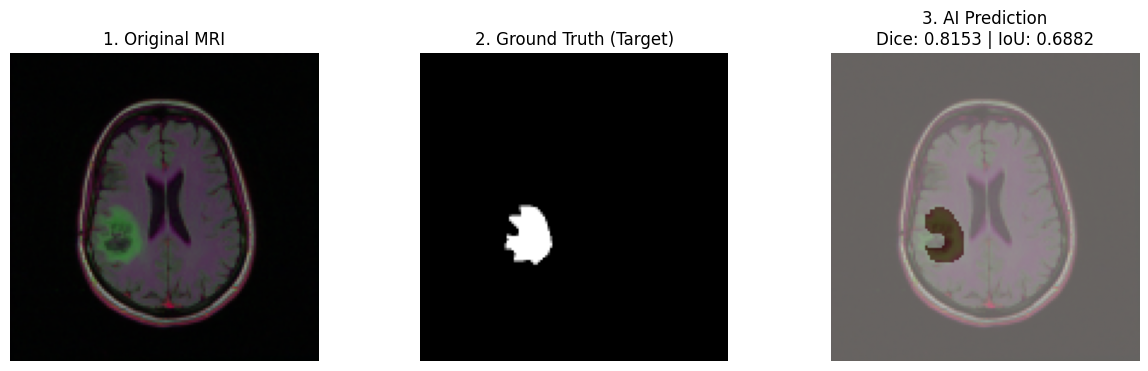

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


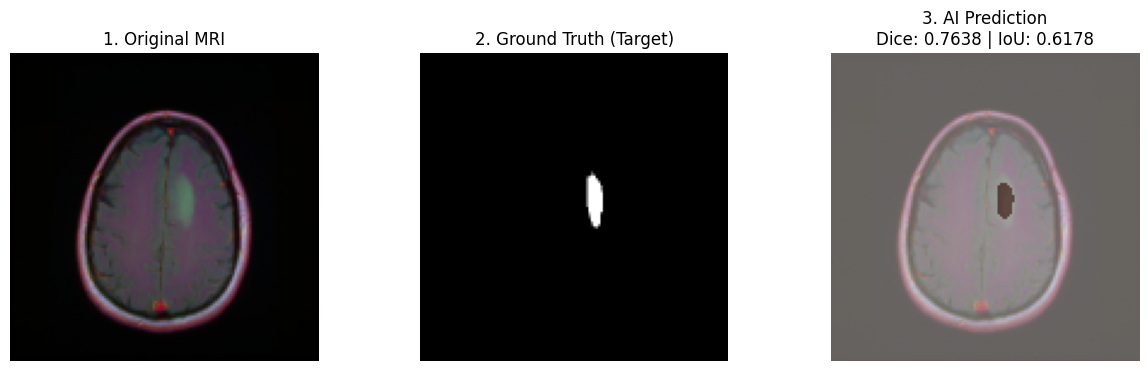

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


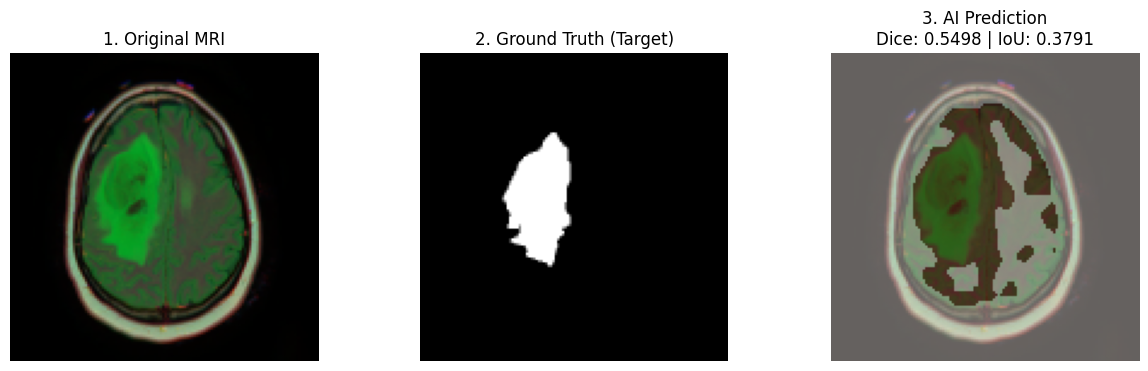

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


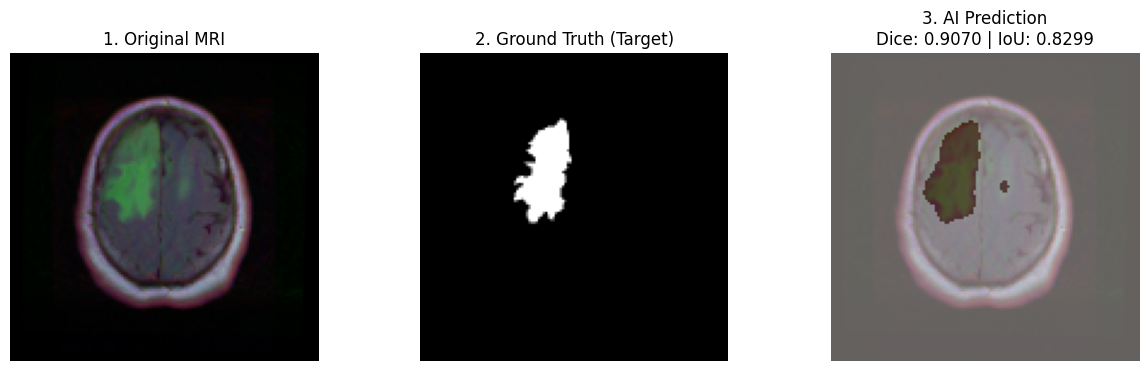

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


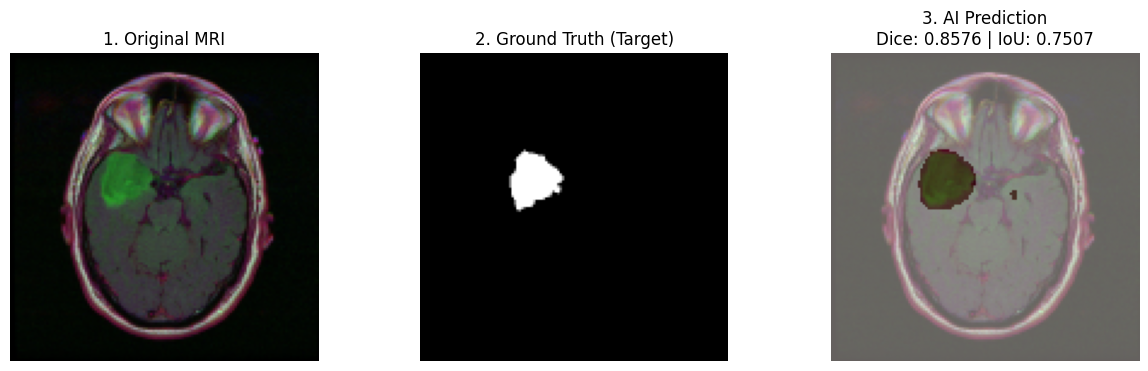

In [18]:
def show_results_with_metrics(num=4):
    import matplotlib.pyplot as plt

    # Select random samples from the test set
    indices = np.random.choice(len(X_test), num)

    for idx in indices:
        img = X_test[idx]
        truth = y_test[idx]

        # 1. Get AI Prediction
        pred = model.predict(np.expand_dims(img, axis=0))[0]
        pred_bin = (pred > 0.5).astype(np.float32) # Convert to binary mask

        # 2. Calculate Individual Metrics for this specific image

        smooth = 1e-7
        intersection = np.sum(pred_bin * truth)

        # Dice = (2 * intersection) / (total_pixels_in_both)
        dice = (2. * intersection + smooth) / (np.sum(pred_bin) + np.sum(truth) + smooth)

        # IoU = intersection / (union)
        iou = (intersection + smooth) / (np.sum(pred_bin) + np.sum(truth) - intersection + smooth)

        # 3. Plotting
        plt.figure(figsize=(15, 4))

        # MRI Input
        plt.subplot(1, 3, 1)
        plt.title("1. Original MRI")
        plt.imshow(img)
        plt.axis('off')

        # Ground Truth (Doctor's Mask)
        plt.subplot(1, 3, 2)
        plt.title("2. Ground Truth (Target)")
        plt.imshow(truth.squeeze(), cmap='gray')
        plt.axis('off')

        # AI Output with Overlay
        plt.subplot(1, 3, 3)
        # Color red for detection overlay
        plt.imshow(img)
        plt.imshow(pred_bin.squeeze(), cmap='Reds', alpha=0.4)
        plt.title(f"3. AI Prediction\nDice: {dice:.4f} | IoU: {iou:.4f}")
        plt.axis('off')

        plt.show()

show_results_with_metrics(5)

In [19]:
all_images = glob(os.path.join(path, "**/*[!mask].tif"), recursive=True)
X, y = [], []

print("Loading a larger, filtered dataset...")
for img_path in all_images:
    mask_path = img_path.replace(".tif", "_mask.tif")
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Only load if tumor is present
        if np.max(mask) > 0:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))
            mask = cv2.resize(mask, (128, 128))

            X.append(img / 255.0)
            y.append(mask / 255.0)

    # Increase this limit to train on more data
    if len(X) >= 1500:
        break

X = np.array(X)
y = np.expand_dims(np.array(y), axis=-1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print(f"Dataset Size: {len(X)} images found with tumors.")

Loading a larger, filtered dataset...
Dataset Size: 1500 images found with tumors.


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define Augmentation
data_gen_args = dict(rotation_range=20,
                     width_shift_range=0.1,
                     height_shift_range=0.1,
                     horizontal_flip=True,
                     vertical_flip=True,
                     fill_mode='nearest')

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# 2. Create the Generator Function
def combine_generator(gen1, gen2):
    while True:
        yield next(gen1), next(gen2)

# 3. Initialize the generators with the same seed
seed = 42
image_gen = image_datagen.flow(X_train, batch_size=16, seed=seed)
mask_gen = mask_datagen.flow(y_train, batch_size=16, seed=seed)

# This is the "Adapter" that fixes the ValueError
train_generator = combine_generator(image_gen, mask_gen)

# 4. Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 16,
    validation_data=(X_test, y_test),
    epochs=50
)

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.9740 - dice_coef: 0.6584 - iou_coef: 0.4977 - loss: 0.3416 - val_accuracy: 0.9805 - val_dice_coef: 0.6920 - val_iou_coef: 0.5327 - val_loss: 0.3195
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 104ms/step - accuracy: 0.9746 - dice_coef: 0.6704 - iou_coef: 0.5090 - loss: 0.3283 - val_accuracy: 0.9811 - val_dice_coef: 0.6860 - val_iou_coef: 0.5249 - val_loss: 0.3078
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.9752 - dice_coef: 0.6759 - iou_coef: 0.5153 - loss: 0.3246 - val_accuracy: 0.9820 - val_dice_coef: 0.6644 - val_iou_coef: 0.5055 - val_loss: 0.3032
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 108ms/step - accuracy: 0.9754 - dice_coef: 0.6774 - iou_coef: 0.5161 - loss: 0.3227 - val_accuracy: 0.9824 - val_dice_coef: 0.6248 - val_iou_coef: 0.4768 - val_loss: 0.3078
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.9758 - dice_coef: 0.6846 - iou_coef: 0.5261 - loss: 0.3159 - val_accuracy: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


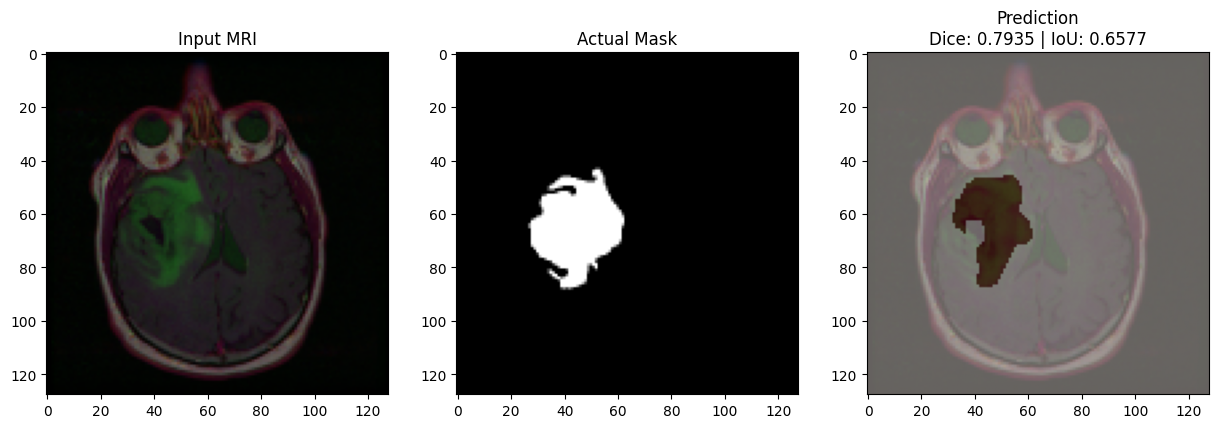

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


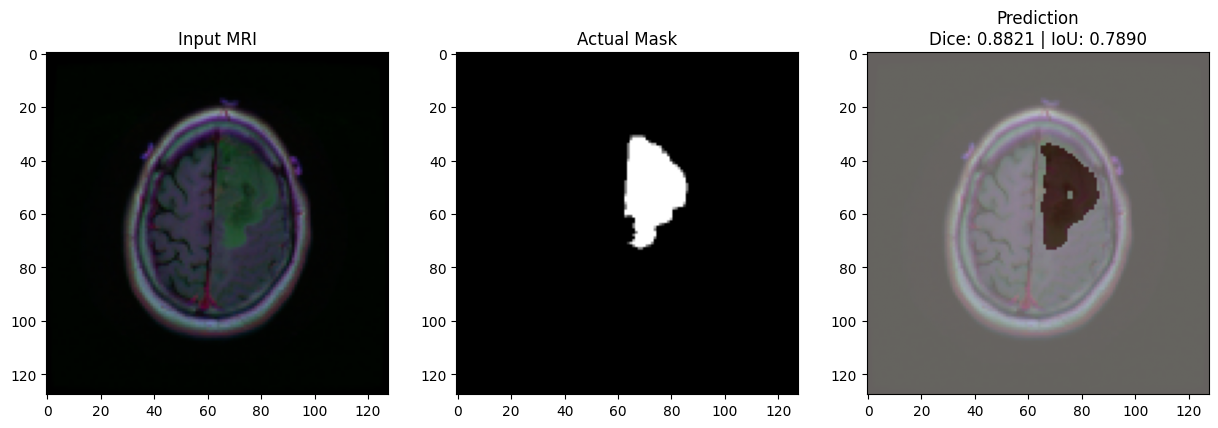

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


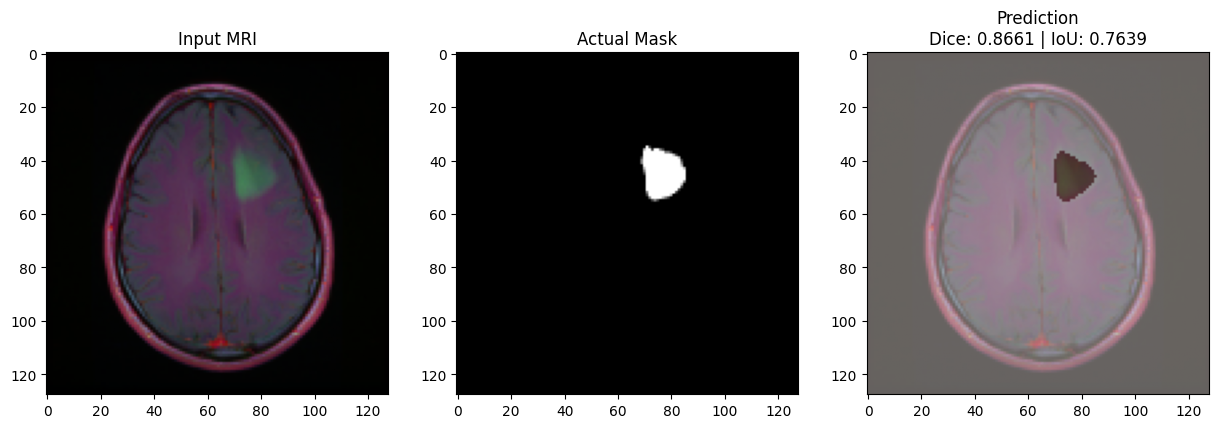

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


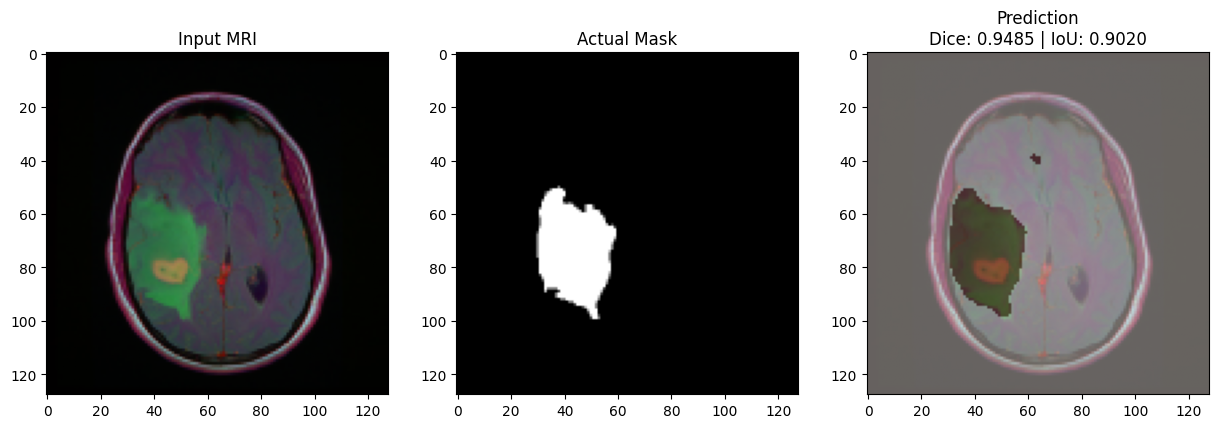

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


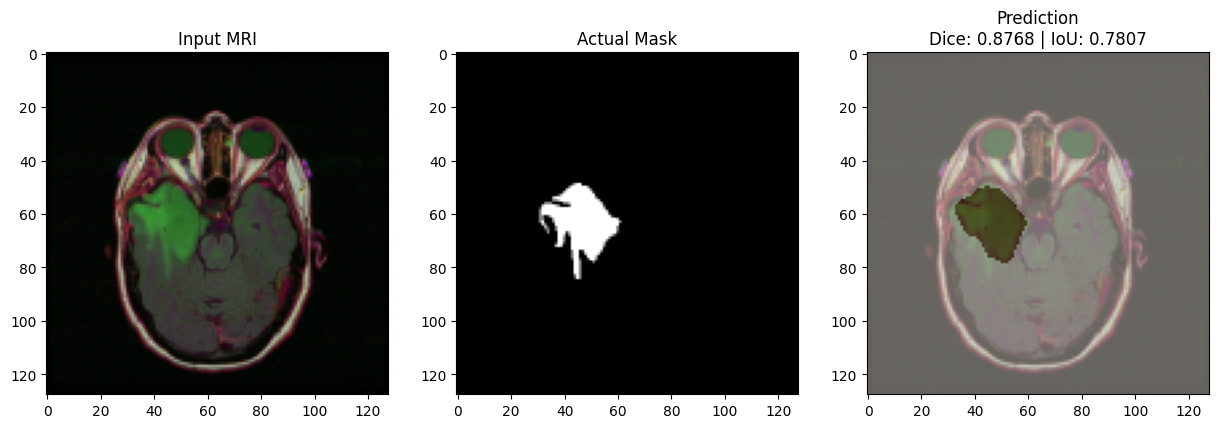

In [27]:
def verify_final_model(num=5):
    indices = np.random.choice(len(X_test), num)

    for idx in indices:
        img = X_test[idx]
        truth = y_test[idx]

        pred = model.predict(np.expand_dims(img, axis=0))[0]
        pred_bin = (pred > 0.5).astype(np.float32)

        # Math for metrics
        intersection = np.sum(pred_bin * truth)
        dice = (2. * intersection + 1e-7) / (np.sum(pred_bin) + np.sum(truth) + 1e-7)
        iou = (intersection + 1e-7) / (np.sum(pred_bin) + np.sum(truth) - intersection + 1e-7)

        # Plot
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(img); ax[0].set_title("Input MRI")
        ax[1].imshow(truth.squeeze(), cmap='gray'); ax[1].set_title("Actual Mask")
        ax[2].imshow(img); ax[2].imshow(pred_bin.squeeze(), cmap='Reds', alpha=0.4)
        ax[2].set_title(f"Prediction\nDice: {dice:.4f} | IoU: {iou:.4f}")
        plt.show()

verify_final_model(5)